# 1_Cálculo del valor de decisón óptimo y probabilidad de error en canales AWGN.

Considere un sistema de comunicaciones en donde el transmisor transmite dos hipótesis $H$ igualmente probables. Bajo la hipótesis $H=0$, la señal observada $Y$ por el receptor a la salida del canal es igual a $-1 + Z$ donde $Z$ es una variable aleatoria Gaussiana $N(0,2)$.

Bajo la hipótesis $H=1$, $Y$ viene dado por $2 + Z$.

1. Exprese matemáticamente las funciones de densidad de probabilidad condicional $f_{Y|H}(y|0)$ y $f_{Y|H}(y|1)$.
2. Realice un programa en una Jupyter Notebook que dibuje las funciones de densidad de probabilidad $f_{Y|H}(y|0)$ y $f_{Y|H}(y|1)$.
3. Determine cualitativamente el nivel de decisión óptimo. ¿Bajo qué regla la decisión es óptima?
4. Determine cuantitativamente el nivel de decisión óptimo.
5. Exprese la probabilidad de error $P_e$ en términos de la función Q.
6. Utilice el siguiente código en Python para calcular el valor de Q con los argumentos obtenidos en el punto anterior:
   

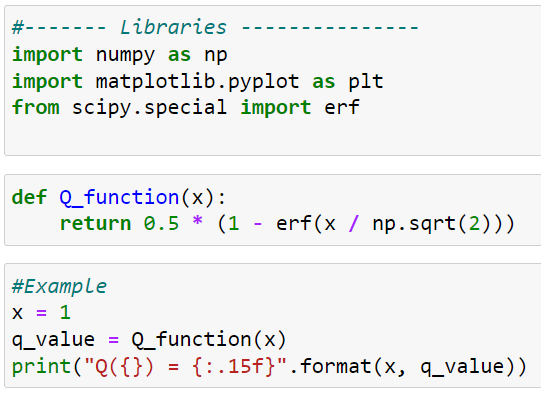



### 1. Exprese matemáticamente las funciones de densidad de probabilidad condicional $f_{Y|H}(y|0)$ y $f_{Y|H}(y|1)$.

Para la hipótesis $H=0$, donde $Y = -1 + Z$, siendo $Z \sim N(0, 2)$, la función de densidad de probabilidad condicional de $Y$ dado que $H=0$ es:
$$
\Large f_{Y|H}(y|0) = \frac{1}{\sqrt{4\pi}} e^{-\frac{(y+1)^2}{4}}
$$

Para la hipótesis $H=1$, donde $Y = 2 + Z$, siendo $Z \sim N(0, 2)$, la función de densidad de probabilidad condicional de $Y$ dado que $H=1$ es:
$$
\Large f_{Y|H}(y|1) = \frac{1}{\sqrt{4\pi}} e^{-\frac{(y-2)^2}{4}}
$$


### 2. Realice un programa en una Jupyter Notebook que dibuje las funciones de densidad de probabilidad $f_{Y|H}(y|0)$ y $f_{Y|H}(y|1)$.

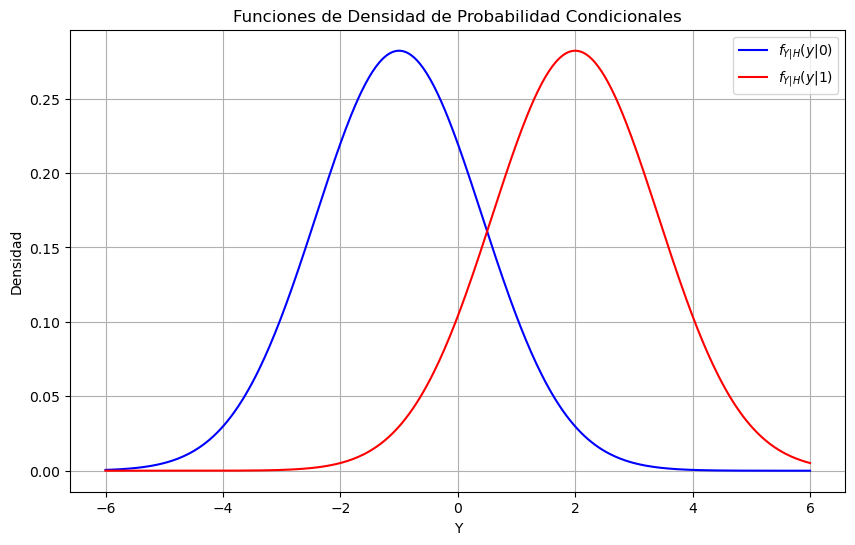

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Definir las funciones de densidad para cada hipótesis
def f_y_given_h0(y):
    return norm.pdf(y, loc=-1, scale=np.sqrt(2))

def f_y_given_h1(y):
    return norm.pdf(y, loc=2, scale=np.sqrt(2))

# Generar un rango de valores de y para evaluar las funciones de densidad
y_values = np.linspace(-6, 6, 400)

# Calcular los valores de las funciones de densidad para cada hipótesis
pdf_h0 = f_y_given_h0(y_values)
pdf_h1 = f_y_given_h1(y_values)

# Crear un gráfico para visualizar las funciones de densidad
plt.figure(figsize=(10, 6))
plt.plot(y_values, pdf_h0, label='$f_{Y|H}(y|0)$', color='blue')
plt.plot(y_values, pdf_h1, label='$f_{Y|H}(y|1)$', color='red')
plt.title('Funciones de Densidad de Probabilidad Condicionales')
plt.xlabel('Y')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()

### 3. Determine cualitativamente el nivel de decisión óptimo. ¿Bajo qué regla la decisión es óptima?

Al observa la gráfica podemos sabremos que el nivel de decisión se encontrará en la intersección de ambas gráficas. Además, al leer con claridad el enunciado, sabremos que la regla optima para determinar el nivel de decisión optimo será la regla ML. Esto es así porque nuestras hipotesis son equiprobables.

### 4. Determine cuantitativamente el nivel de decisión óptimo.

Para encontrar cuantitativamente el nivel de decisión, utilizando la regla ML, debemos igualar ambas probabilidades condicionales. De la siguiente manera:

$$
\Large \frac{1}{\sqrt{4\pi}} e^{-\frac{(y+1)^2}{4}} = \frac{1}{\sqrt{4\pi}} e^{-\frac{(y-2)^2}{4}}
$$

##### Resolvemos analiticamente

1. Podemos simplificar eliminando los términos comunes:  

$$
\Large e^{-\frac{(y+1)^2}{4}} = e^{-\frac{(y-2)^2}{4}}
$$

2. Tomando el logaritmo natural de ambos lados:

$$
\Large -\frac{(y+1)^2}{4} = -\frac{(y-2)^2}{4}
$$

3. Multiplicando ambos lados por $-4$ para despejar los exponentes y simplificar:

$$
\Large (y+1)^2 = (y-2)^2
$$

4. Expandiendo ambos cuadrados:

$$
\Large y^2 + 2y + 1 = y^2 - 4y + 4
$$

5. Simplificando y resolviendo para $y$:

$$
\Large 2y + 4y = 4 - 1
$$
$$
\Large 6y = 3
$$
$$
\Large y = \frac{3}{6} = 0,5
$$


Finalmente obtenemos que nuestro nivel de decisión es 0,5, en concordancia con lo que observa en el gráfico.

#### 5. Exprese la probabilidad de error $P_e$ en términos de la función Q.


Primero debemos normalizar ambas funciones de Y, tanto para H=1 como para H=0, para poder utilizar la función Q. Utilizaremos una variable Z, que será la normalización de Y:

$$
Z = \frac{Y - \mu}{\sigma}
$$

##### Hipotesís H=0

La variable $Z$ normalizada para H=0 se calcula como:

$$
\Large Z = \frac{Y + 1}{\sqrt{2}}
$$

Luego, aplicamos $Q$ al valor del nivel de decisión:

$$
\Large Q\left(\frac{0.5 + 1}{\sqrt{2}}\right) = Q\left(\frac{1.5}{\sqrt{2}}\right)
$$
La probabilidad de error, cuando Y es mayor al nivel de decisión, de que se seleccione erroneamente H=1 sobre H=0:
$$
\Large P_{e|H_1} = Q\left(\frac{1.5}{\sqrt{2}}\right)
$$


##### Hipotesís H=1

La variable $Z$ normalizada para H=1 se calcula como:

$$
\Large Z = \frac{Y - 2}{\sqrt{2}}
$$

Luego, aplicamos $Q$ al valor del nivel de decisión:

$$
\Large Q\left(\frac{0.5 - 2}{\sqrt{2}}\right) = Q\left(\frac{-1.5}{\sqrt{2}}\right)
$$

La probabilidad de error, cuando Y es menor al nivel de decisión, de que se seleccione erroneamente H=0 sobre H=1. Utilizamos 1-Q porque estamos buscando la cola derecha de la función, aquella que está por debajo de nuestro nivel de decisión:
$$
\Large P_{e|H_1} = 1 - Q\left(\frac{-1.5}{\sqrt{2}}\right)
$$



##### Pe en función de Q

Sabiendo que la probabilidad total de error $P_e$ se calcula combinando las probabilidades de error bajo las hipótesis $H=0$ y $H=1$, se obtiene lo siguiente:
$$
\Large P_e = \frac{1}{2} (P_{e|H_0} + P_{e|H_1})
$$

Teniendo en cuenta las expresiones de las probabilidades en función de la función Q, obtendremos lo siguiente:

$$
P_e = \frac{1}{2} \left[ Q\left(\frac{1.5}{\sqrt{2}}\right) + (1 - Q\left(\frac{-1.5}{\sqrt{2}}\right)) \right]
$$

Simplificando la expresión, utilizando la naturaleza simetríca de la función Q:

$$
P_e = \frac{1}{2} \left[ 2Q\left(\frac{1.5}{\sqrt{2}}\right) - 1 + 1 \right]
$$

Esto resulta en:

$$
P_e = Q\left(\frac{1.5}{\sqrt{2}}\right)
$$


#### 6. Utilice el siguiente código en Python para calcular el valor de Q con los argumentos obtenidos en el punto anterior:

In [6]:
from scipy.special import erf
import numpy as np

def Q_Function(x):
    return 0.5 * (1 - erf(x / np.sqrt(2)))

# Defino el valor de x
x = 1.5

# Calcula Q(x)
Q_x = Q_Function(x)

print("Q({}) = {:.15F}".format(x, Q_x))

Q(1.5) = 0.066807201268858
